<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/06_kendi_hedefin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kapanış: kendi hedefini seç

Serinin son defteri ve bu kez sonucu siz üreteceksiniz. Dört rehberde kurduğumuz adımları tek bir akışa topluyoruz: bir kanser tipi seçin, o tipte seçici bağımlılık gösteren genleri bulun, adaylardan birini mutasyonla ilişkilendirin ve elemelerden geçirin.

Kod hazır ve parametrik; değiştireceğiniz tek şey en üstteki iki satır.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KLASOR = '/content/drive/MyDrive/melisa-ile-biyoinformatik'
KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)

mut_ham = pd.read_csv(f'{KLASOR}/OmicsSomaticMutationsMatrixHotspot.csv')
kalip = re.compile(r'^\S.* \(.+\)$')
gen_sutun = [c for c in mut_ham.columns if kalip.match(c)]
bayrak = mut_ham['IsDefaultEntryForModel'].astype(str).str.lower().isin(['yes', 'true'])
mut = mut_ham[bayrak].set_index('ModelID')[gen_sutun].groupby(level=0).max()
ortak = skor.index.intersection(mut.index)

ESIK = -1.0
print('hazır | skor:', skor.shape, '| mutasyon:', mut.shape, '| ortak hat:', len(ortak))

Mounted at /content/drive
hazır | skor: (1208, 5000) | mutasyon: (1968, 554) | ortak hat: 1208


## 1. Kanser tipini seçmek

Aşağıdaki listeden bir doku seçin. Yeterli hat sayısı önemli: 20'nin altındaki dokularda oranlar tek bir hattın yer değiştirmesiyle oynar, dolayısıyla sonuç kırılgan olur.

In [2]:
print(kunye['OncotreeLineage'].value_counts().head(20).to_string())

OncotreeLineage
Lung                         126
Lymphoid                      96
CNS/Brain                     91
Head and Neck                 77
Skin                          75
Esophagus/Stomach             69
Bowel                         63
Ovary/Fallopian Tube          59
Bone                          58
Breast                        53
Soft Tissue                   49
Pancreas                      48
Peripheral Nervous System     47
Myeloid                       45
Kidney                        35
Uterus                        34
Biliary Tract                 34
Bladder/Urinary Tract         34
Liver                         25
Pleura                        21


In [3]:
DOKU = 'Pancreas'          # <-- kendi seçiminizi yazın

hedef_hat = kunye.index[kunye.OncotreeLineage == DOKU]
diger_hat = kunye.index.difference(hedef_hat)
print(f'{DOKU}: {len(hedef_hat)} hat | diğer: {len(diger_hat)} hat')

Pancreas: 48 hat | diğer: 1160 hat


## 2. Bu dokuya özgü bağımlılıkları bulmak

Ölçüt 4.4'ün mantığını bir adım ileri taşıyor. Orada "bazı hatlarda ölümcül" diyorduk; burada "*bu dokudaki* hatlarda ölümcül, diğerlerinde değil" diyoruz. Üç koşul:

1. Seçilen dokudaki hatların en az yüzde 30'u bağımlı (skor < −1) — sinyal o dokuda yaygın olsun.
2. Diğer dokulardaki bağımlılık oranı yüzde 10'un altında — terapötik pencere açık kalsın.
3. Aradaki medyan farkı en az 0,3 — fark yalnız eşik oyunundan doğmasın.

Eşiklerin hepsi karardır ve raporda yazılır; oynatıp listenin nasıl değiştiğini görmek bu defterin en öğretici denemesi.

In [4]:
h = skor.loc[hedef_hat]
d = skor.loc[diger_hat]

tablo = pd.DataFrame({
    'sembol': [c.split(' ')[0] for c in skor.columns],
    'hedef_oran': (h < ESIK).mean(),
    'diger_oran': (d < ESIK).mean(),
    'hedef_medyan': h.median(),
    'diger_medyan': d.median(),
})
tablo['fark'] = tablo.diger_medyan - tablo.hedef_medyan

adaylar = tablo[(tablo.hedef_oran >= 0.30) &
                (tablo.diger_oran < 0.10) &
                (tablo.fark >= 0.30)].sort_values('fark', ascending=False)

print(f'{DOKU} için aday sayısı:', len(adaylar))
print(adaylar.head(15).round(3).to_string(index=False))

Pancreas için aday sayısı: 1
sembol  hedef_oran  diger_oran  hedef_medyan  diger_medyan  fark
NCKAP1       0.354       0.084        -0.791        -0.454 0.336


## 3. Bir adayı yakından incelemek

Listeden bir gen seçin ve profilini çizin: seçtiğiniz dokudaki hatlarla diğerlerinin skor dağılımı yan yana. 4.3'ün mantığı, bu kez tek gen yerine tek doku etrafında.

incelenen gen: NCKAP1 (10787)


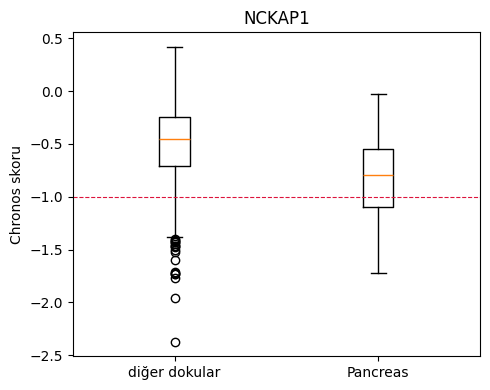

In [5]:
GEN = adaylar.index[0]              # <-- listeden başka bir gen de seçebilirsiniz
print('incelenen gen:', GEN)

plt.figure(figsize=(5, 4))
plt.boxplot([d[GEN].dropna().values, h[GEN].dropna().values],
            tick_labels=['diğer dokular', DOKU])
plt.axhline(ESIK, ls='--', lw=0.8, c='crimson')
plt.ylabel('Chronos skoru'); plt.title(GEN.split(' ')[0])
plt.tight_layout();

## 4. Mutasyonla ilişkilendirmek

4.5'in sorusu: bu bağımlılık bir mutasyonla açıklanıyor mu? Gen hotspot matrisinde varsa mutant ve yabanıl hatları karşılaştırıyoruz. Yoksa, bu da bir bulgudur — bağımlılığın nedeni hotspot mutasyonu değil demektir; sebep paralog kaybı, ifade düzeyi ya da doku kökenli bağımlılık olabilir.

In [6]:
sembol = GEN.split(' ')[0]
mc = next((c for c in mut.columns if c.split(' ')[0] == sembol), None)

if mc is None:
    print(f'{sembol}: hotspot matrisinde yok — bağımlılık hotspot mutasyonuyla açıklanmıyor')
else:
    k = pd.DataFrame({'skor': skor.loc[ortak, GEN],
                      'mutant': (mut.loc[ortak, mc] > 0).astype(int)}).dropna()
    m1, m0 = k[k.mutant == 1].skor, k[k.mutant == 0].skor
    print(f'{sembol}  mutant: {len(m1)} hat, medyan {m1.median():.2f} | '
          f'yabanıl: {len(m0)} hat, medyan {m0.median():.2f}')

NCKAP1: hotspot matrisinde yok — bağımlılık hotspot mutasyonuyla açıklanmıyor


## 5. Eleme listesi

Bir aday, hedef olarak önerilmeden önce şu sorulardan geçer. Hiçbiri kod değil, hepsi yorum:

1. **Ortak esansiyel mi?** Diğer dokulardaki bağımlılık oranınız zaten bunu filtreledi, ama adayın genel medyanına da bakın — 4.2'nin dersi.
2. **Grup yeterince büyük mü?** Seçtiğiniz dokudaki hat sayısı ve bağımlı hat sayısı, sonucu taşıyacak kadar büyük mü?
3. **Sonuç bilinen biyolojiyle uyuşuyor mu?** Gen o kanser tipinde tanınan bir yolağın parçası mı? Uyuşmuyorsa yanlış demek değil, ama açıklama gerektirir.
4. **Hedeflenebilir mi?** Ürünü ilaçla bağlanabilir bir protein mi? Transkripsiyon faktörleri ve yapısal proteinler zordur.
5. **Hangi kanıt eksik?** Bunlar hücre hattı verileri: mikroçevre, bağışıklık sistemi ve damarlanma yok. Bir sonraki adım ne olurdu?

## Kendin dene: bitirme görevi

Bu serinin son görevi kısa bir rapor yazmak. Beş maddede toplayın:

1. Seçtiğiniz kanser tipi ve hat sayısı.
2. Aday sayınız ve en güçlü üç adayın adı, oranları, medyan farkı.
3. Yakından incelediğiniz genin adı ve kutu grafiğinin tek cümlelik yorumu.
4. Mutasyon karşılaştırmasının sonucu — açıklıyor mu, açıklamıyor mu?
5. Yukarıdaki eleme listesinden geçirdiğinizde bu adayı önerir miydiniz, neden?

Rapor yarım sayfa; ama bu yarım sayfa, gerçek bir hedef keşfi çalışmasının ilk adımının aynısı.